In [1]:
!wget -O shape_predictor_68_face_landmarks.dat.bz2 http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bzip2 -d shape_predictor_68_face_landmarks.dat.bz2
!ls -lh shape_predictor_68_face_landmarks.dat
import dlib
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")
print("Loaded successfully ✅")

--2026-04-08 22:44:00--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-04-08 22:44:00--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  33.4MB/s    in 1.8s    

2026-04-08 22:44:02 (33.4 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

-rw-r--r-- 1 root root 96M Jul 24  2015 shape_predictor_68_face_landmarks.dat
Loaded successfully ✅


Found preprocess folder at: facial_recognition-main/processed_data
Processing all images...


0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 2/2 [00:00<00:00,  6.76it/s]
0it [00:00, ?it/s]
100%|██████████| 7/7 [00:00<00:00,  7.41it/s]
0it [00:00, ?it/s]
100%|██████████| 2/2 [00:00<00:00,  8.16it/s]



Feature extraction complete! Saved to face_embeddings.npz


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded embeddings file: face_embeddings.npz


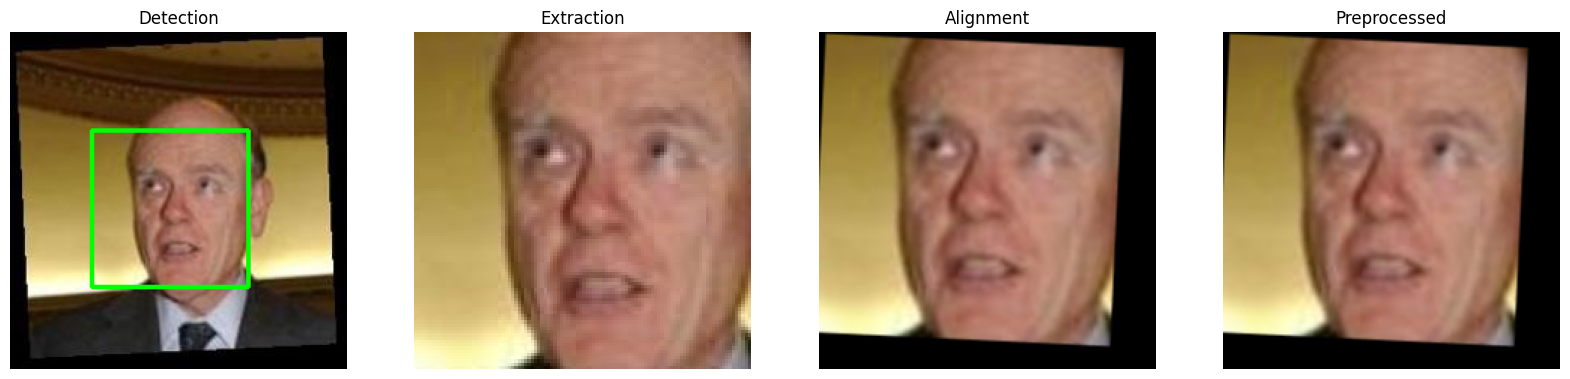

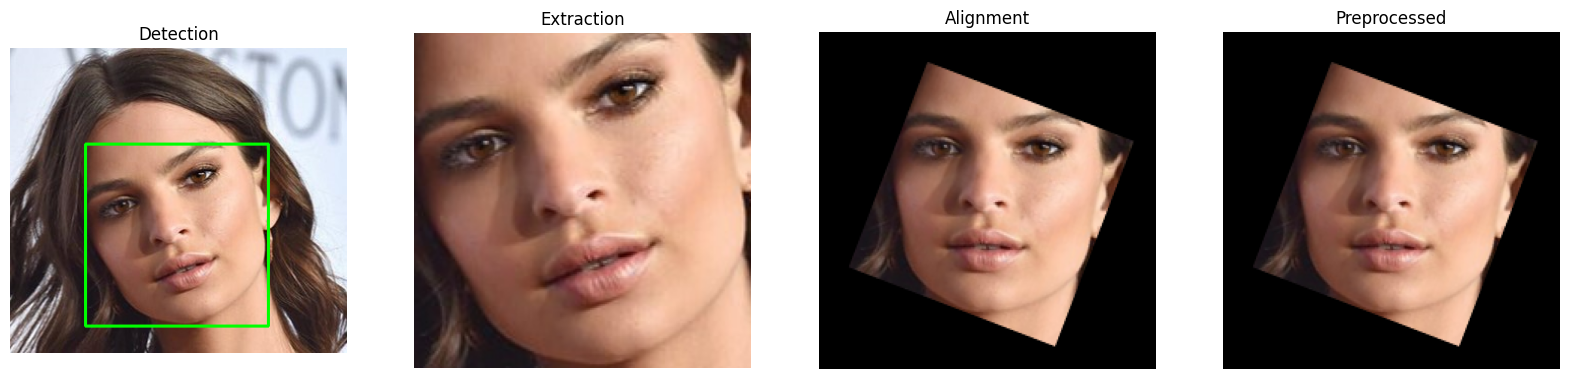

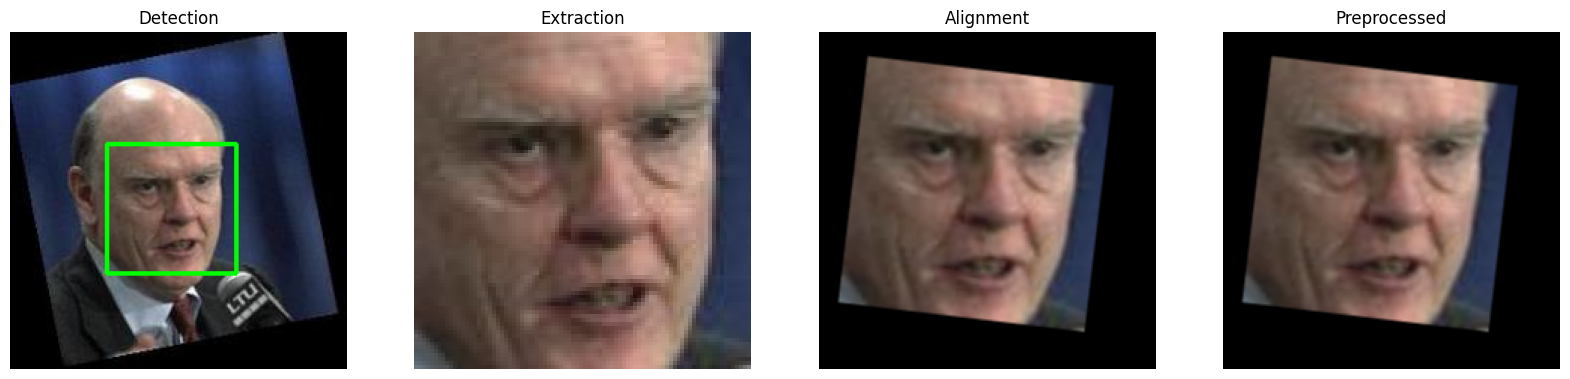

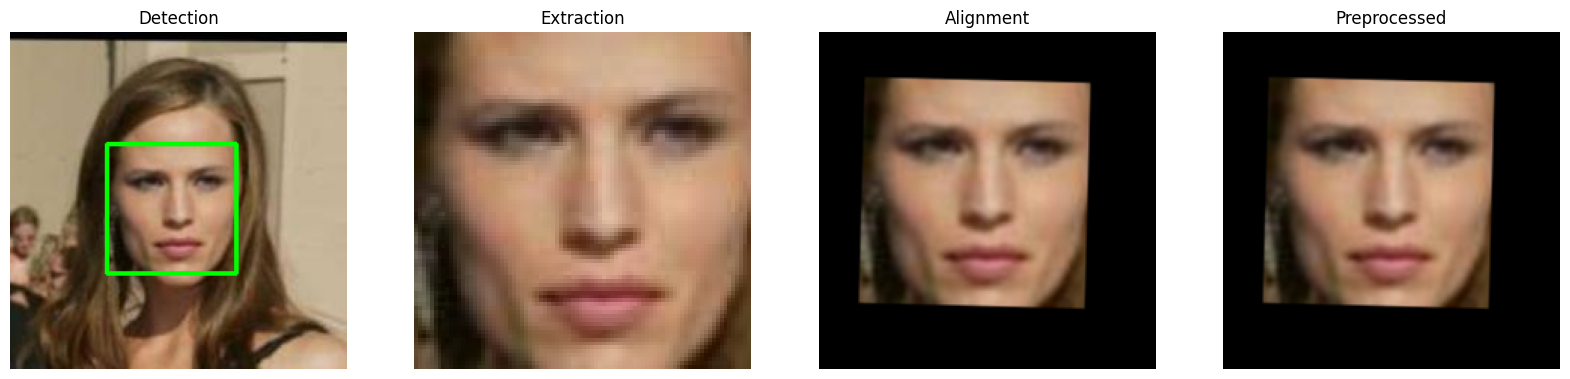

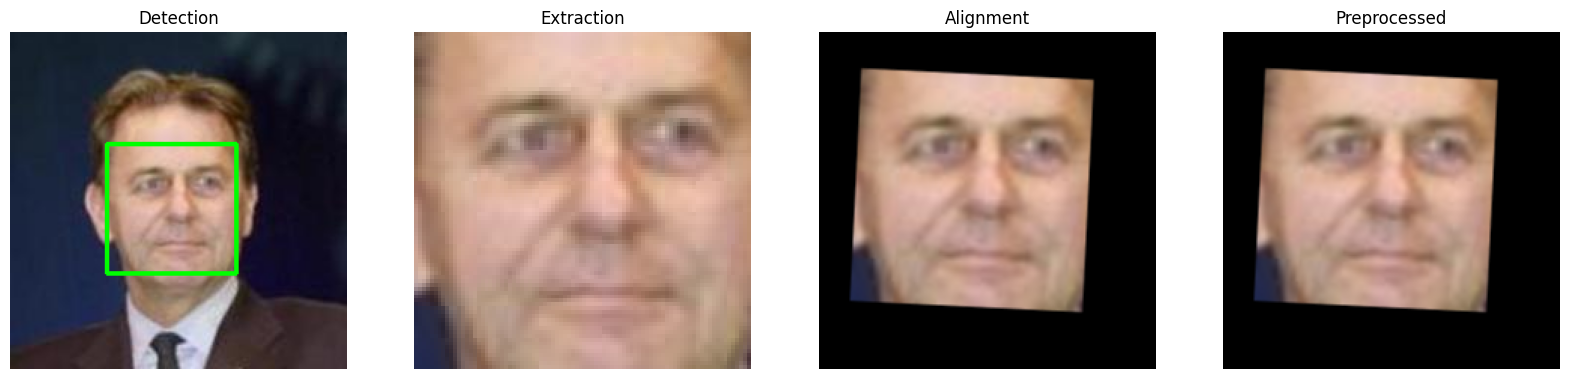

In [6]:
# --- INSTALL DEPENDENCIES ---
!pip install opencv-python dlib matplotlib requests tqdm face_recognition

# --- IMPORT LIBRARIES ---
import os
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import requests
from zipfile import ZipFile
import shutil
import random
import face_recognition
from google.colab import files
import time

# --- SETTINGS ---
github_repo_zip_url = "https://github.com/Nayanapmku/facial_recognition/archive/refs/heads/main.zip"
local_repo_zip = "repo.zip"
preprocess_dir_name = "processed_data"
output_dir = "preprocess_aligned"
output_feature_file = "face_embeddings.npz"

# Face alignment settings
predictor_path = "shape_predictor_68_face_landmarks.dat"  # ensure this file exists
desired_size = 224
desired_left_eye = (0.35, 0.35)
desired_right_eye_x = 1.0 - desired_left_eye[0]

# Number of sample images for summary visualization
num_display = 5

# --- DOWNLOAD AND EXTRACT DATA REPO ---
if not os.path.exists(preprocess_dir_name):
    print("Downloading repo from GitHub...")
    r = requests.get(github_repo_zip_url, stream=True)
    with open(local_repo_zip, 'wb') as f:
        for chunk in r.iter_content(chunk_size=1024):
            if chunk:
                f.write(chunk)

    with ZipFile(local_repo_zip, 'r') as zip_ref:
        zip_ref.extractall(".")

    # Automatically find preprocess folder
    extracted_dirs = [d for d in os.listdir() if os.path.isdir(d)]
    preprocess_dir = None
    for d in extracted_dirs:
        if preprocess_dir_name in os.listdir(d):
            preprocess_dir = os.path.join(d, preprocess_dir_name)
            break

    if preprocess_dir is None:
        raise FileNotFoundError(f"Could not find '{preprocess_dir_name}' folder in the repo!")
    else:
        print(f"Found preprocess folder at: {preprocess_dir}")
else:
    preprocess_dir = preprocess_dir_name
    print(f"Using existing preprocess folder: {preprocess_dir}")

# --- LOAD DLIB PREDICTOR AND FACE DETECTOR ---
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")
detector = dlib.get_frontal_face_detector()

# --- UTILITY FUNCTIONS ---
def detect_faces(img_rgb):
    return detector(img_rgb)

def extract_face(img_rgb, face_rect):
    return img_rgb[face_rect.top():face_rect.bottom(), face_rect.left():face_rect.right()]

def align_face(extracted_face):
    landmarks = predictor(extracted_face, dlib.rectangle(0, 0, extracted_face.shape[1], extracted_face.shape[0]))
    left_eye_pts = np.array([(landmarks.part(j).x, landmarks.part(j).y) for j in range(36,42)])
    right_eye_pts = np.array([(landmarks.part(j).x, landmarks.part(j).y) for j in range(42,48)])
    left_eye_center = left_eye_pts.mean(axis=0)
    right_eye_center = right_eye_pts.mean(axis=0)

    dy = right_eye_center[1] - left_eye_center[1]
    dx = right_eye_center[0] - left_eye_center[0]
    angle = np.degrees(np.arctan2(dy, dx))
    dist = np.sqrt(dx**2 + dy**2)
    desired_dist = (desired_right_eye_x - desired_left_eye[0]) * desired_size
    scale = desired_dist / dist
    eyes_center = ((left_eye_center[0] + right_eye_center[0])/2,
                   (left_eye_center[1] + right_eye_center[1])/2)
    M = cv2.getRotationMatrix2D(eyes_center, angle, scale)
    tX = desired_size * 0.5
    tY = desired_size * desired_left_eye[1]
    M[0,2] += (tX - eyes_center[0])
    M[1,2] += (tY - eyes_center[1])
    aligned_face = cv2.warpAffine(extracted_face, M, (desired_size, desired_size))
    return aligned_face

def preprocess_face(aligned_face, normalize=True):
    preprocessed_face = cv2.resize(aligned_face, (desired_size, desired_size))
    if normalize:
        preprocessed_face = preprocessed_face / 255.0
    return preprocessed_face

def get_embedding(preprocessed_face):
    preprocessed_uint8 = (preprocessed_face*255).astype(np.uint8)
    embedding = face_recognition.face_encodings(preprocessed_uint8)
    return embedding[0] if len(embedding) > 0 else None

def process_image(img_path, output_path, normalize=True):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Cannot read image: {img_path}")
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = detect_faces(img_rgb)
    if len(faces) == 0:
        print(f"No face detected in {img_path}")
        return None
    face = faces[0]
    extracted = extract_face(img_rgb, face)
    aligned = align_face(extracted)
    preprocessed = preprocess_face(aligned, normalize=normalize)

    # Save preprocessed image
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.imsave(output_path, (preprocessed*255).astype(np.uint8))

    embedding = get_embedding(preprocessed)
    if embedding is None:
        print(f"No embedding for {img_path}")
    return embedding

# --- GATHER ALL IMAGE PATHS ---
all_image_paths = []
for root, dirs, files_in_dir in os.walk(preprocess_dir):
    for file in files_in_dir:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            all_image_paths.append(os.path.join(root, file))

display_sample_paths = random.sample(all_image_paths, min(num_display, len(all_image_paths)))

# --- INITIALIZE EMBEDDINGS DATA ---
embeddings_data = {"train_embeddings": [], "train_labels": [],
                   "val_embeddings": [], "val_labels": [],
                   "test_embeddings": [], "test_labels": []}

# --- PROCESS ALL IMAGES ---
print("Processing all images...")
for root, dirs, files_in_dir in os.walk(preprocess_dir):
    for file in tqdm(files_in_dir):
        if file.lower().endswith((".jpg",".jpeg",".png")):
            img_path = os.path.join(root, file)
            rel_path = os.path.relpath(root, preprocess_dir)
            output_path = os.path.join(output_dir, rel_path, file)
            embedding = process_image(img_path, output_path, normalize=True)

            if embedding is not None:
                if "train" in rel_path.lower():
                    embeddings_data["train_embeddings"].append(embedding)
                    embeddings_data["train_labels"].append(os.path.basename(root))
                elif "validation" in rel_path.lower():
                    embeddings_data["val_embeddings"].append(embedding)
                    embeddings_data["val_labels"].append(os.path.basename(root))
                elif "test" in rel_path.lower():
                    embeddings_data["test_embeddings"].append(embedding)
                    embeddings_data["test_labels"].append(os.path.basename(root))

# --- SAVE EMBEDDINGS ---
np.savez(
    output_feature_file,
    train_embeddings=np.array(embeddings_data["train_embeddings"]),
    train_labels=np.array(embeddings_data["train_labels"]),
    val_embeddings=np.array(embeddings_data["val_embeddings"]),
    val_labels=np.array(embeddings_data["val_labels"]),
    test_embeddings=np.array(embeddings_data["test_embeddings"]),
    test_labels=np.array(embeddings_data["test_labels"])
)
print(f"\nFeature extraction complete! Saved to {output_feature_file}")

# --- ZIP AND DOWNLOAD PREPROCESSED DATA AND EMBEDDINGS ---
if os.path.exists(output_dir):
    preprocess_zip_file = output_dir + ".zip"
    if os.path.exists(preprocess_zip_file):
        os.remove(preprocess_zip_file)
    shutil.make_archive(output_dir, 'zip', output_dir)
    time.sleep(2)
    try:
        files.download(preprocess_zip_file)
    except Exception as e:
        print(f"Could not download folder via browser. Check Colab Files panel. Error: {e}")

if os.path.exists(output_feature_file):
    try:
        files.download(output_feature_file)
        print(f"Downloaded embeddings file: {output_feature_file}")
    except Exception as e:
        print(f"Could not download embeddings file. Check Colab Files panel. Error: {e}")

# --- SIDE-BY-SIDE SUMMARY VISUALIZATION ---
def show_summary_pipeline(sample_paths):
    for img_path in sample_paths:
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        faces = detect_faces(img_rgb)
        if len(faces) == 0:
            continue
        face = faces[0]
        img_detected = img_rgb.copy()
        cv2.rectangle(img_detected, (face.left(), face.top()), (face.right(), face.bottom()), (0,255,0), 2)
        extracted = extract_face(img_rgb, face)
        aligned = align_face(extracted)
        preprocessed = preprocess_face(aligned, normalize=False)

        fig, axes = plt.subplots(1,4,figsize=(20,5))
        axes[0].imshow(img_detected); axes[0].set_title("Detection"); axes[0].axis('off')
        axes[1].imshow(extracted); axes[1].set_title("Extraction"); axes[1].axis('off')
        axes[2].imshow(aligned); axes[2].set_title("Alignment"); axes[2].axis('off')
        axes[3].imshow(preprocessed); axes[3].set_title("Preprocessed"); axes[3].axis('off')
        plt.show()

show_summary_pipeline(display_sample_paths)